# 导包

In [12]:
import os
import sys
import pathlib
from typing import Union

import matplotlib.pyplot as plt

# 适配交互式环境和脚本环境的路径获取方式
try:
    # 优先尝试脚本模式的路径获取（.py文件运行时）
    current_dir = os.path.dirname(os.path.realpath(__file__))
except NameError:
    # Jupyter/IPython交互式环境下，使用当前工作目录
    current_dir = os.path.abspath(os.getcwd())

# 获取上级目录并添加到系统路径
parent_dir = os.path.abspath(os.path.join(current_dir, "../../"))
sys.path.append(parent_dir)

import deeperhistreg
from deeperhistreg.dhr_input_output.dhr_loaders import OpenSlideLoader, tiff_loader, LoadMode

# 基本设置

In [2]:
he_path = "/data/med/MMR/MMR-HCMI-HE-SVS/F2025-00089.svs"
ihc_path = "/backup/lzl/data/MMR/IHC/2025-03-05_15_04_40.svs"

he_path = pathlib.Path(he_path)
ihc_path = pathlib.Path(ihc_path)

In [3]:
output_path = "../../test/registration"

if not os.path.exists(output_path):
    os.makedirs(output_path, exist_ok=True)
    print(f"目录已创建：{output_path}")
else:
    print(f"目录已存在：{output_path}")

output_path = pathlib.Path(output_path)

目录已创建：../../test/registration


# 数据预览

## WSI 预览

In [4]:
he_loader = OpenSlideLoader(
    image_path=he_path,
    mode=LoadMode.NUMPY,
)

he_loader.num_levels, he_loader.resolutions

(7,
 [(41152, 38054, 4),
  (10288, 9513, 4),
  (2572, 2378, 4),
  (643, 594, 4),
  (160, 148, 4),
  (40, 37, 4),
  (10, 9, 4)])

In [5]:
ihc_loader = OpenSlideLoader(
    image_path=ihc_path,
    mode=LoadMode.NUMPY,
)

ihc_loader.num_levels, ihc_loader.resolutions

(7,
 [(33090, 68060, 4),
  (8272, 17015, 4),
  (2068, 4253, 4),
  (517, 1063, 4),
  (129, 265, 4),
  (32, 66, 4),
  (8, 16, 4)])

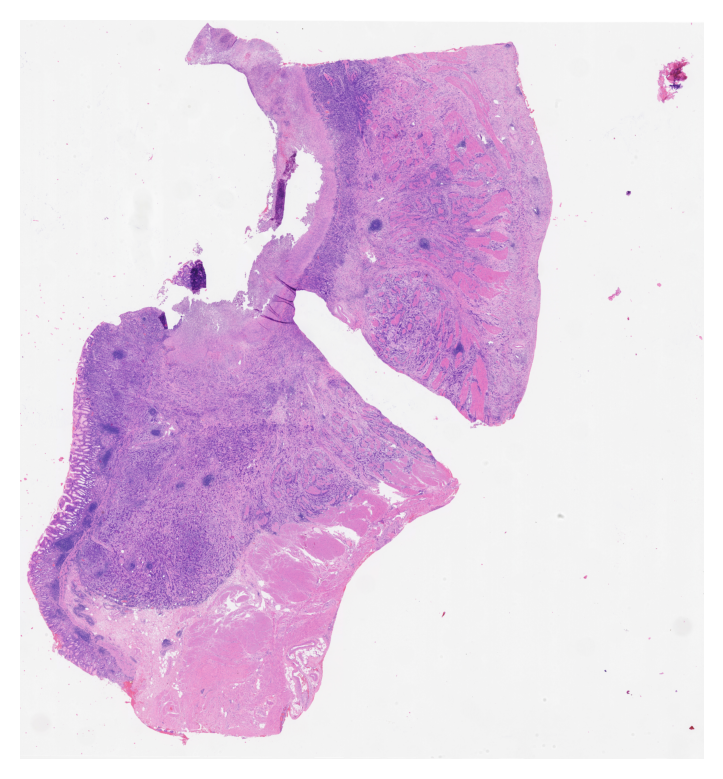

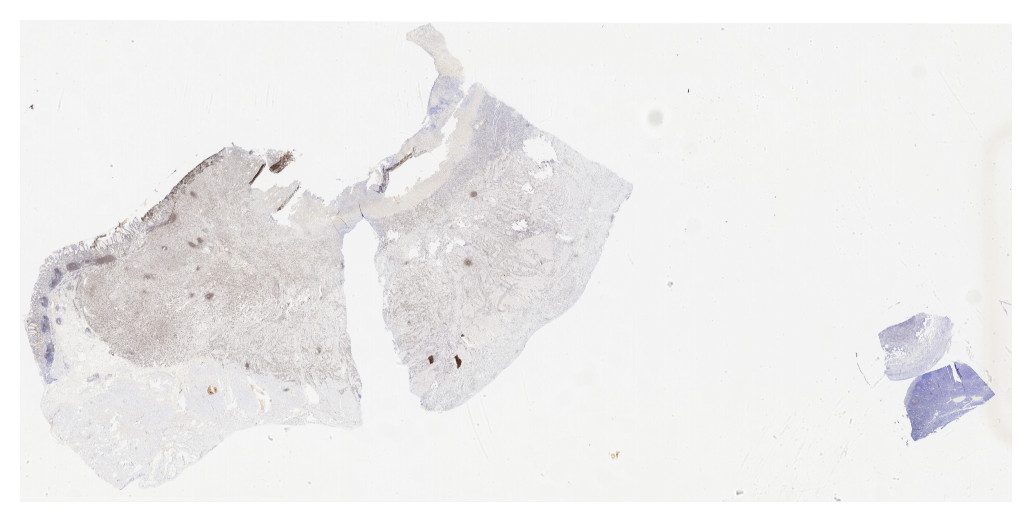

In [6]:
load_level = 1
he_wsi = he_loader.load_level(level=load_level)
ihc_wsi = ihc_loader.load_level(level=load_level)

plt.figure(dpi=200)
plt.imshow(he_wsi)
plt.axis('off')

plt.figure(dpi=200)
plt.imshow(ihc_wsi)
plt.axis('off')

plt.show()

## Patch 预览

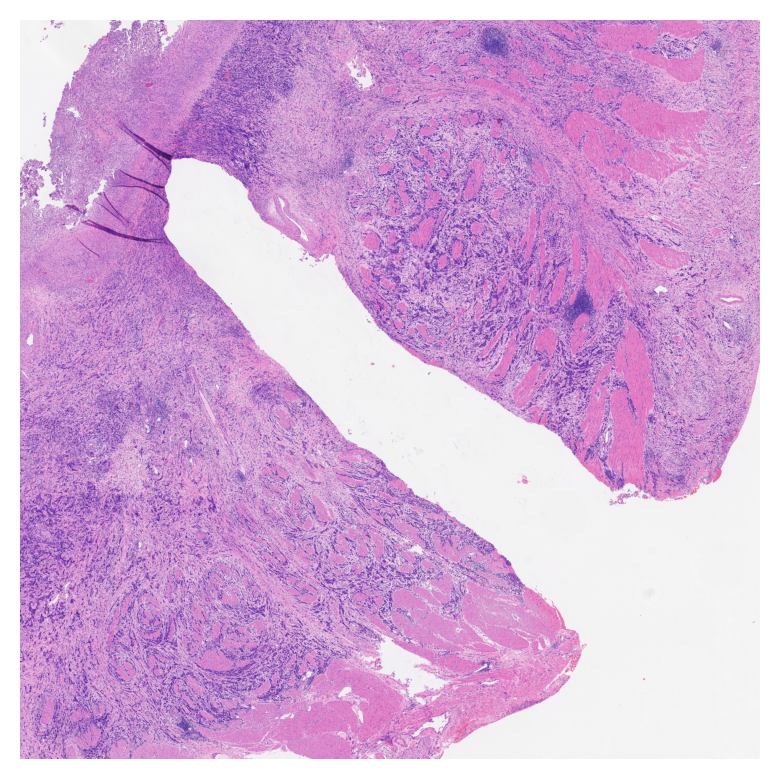

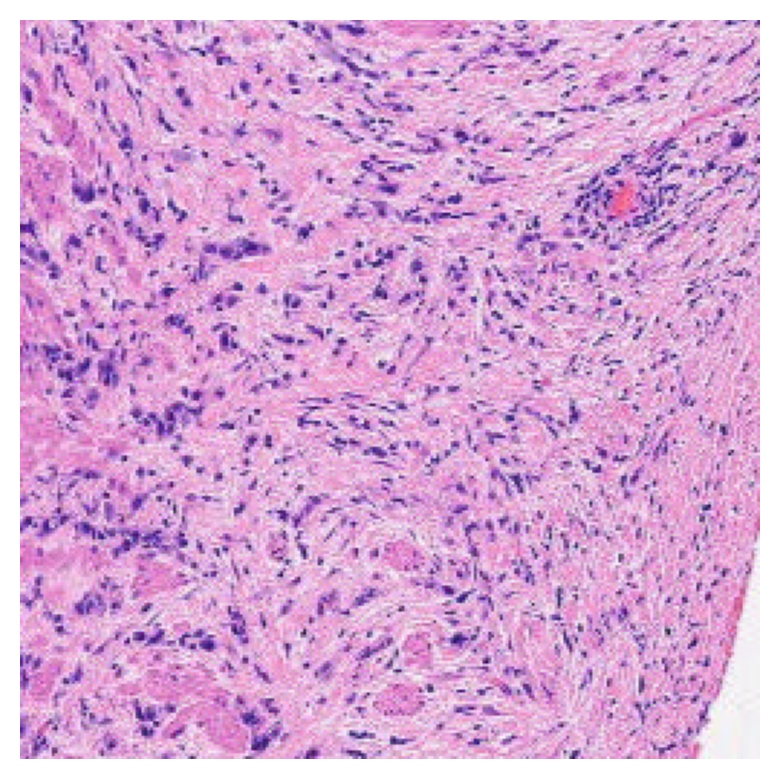

In [7]:
he_region = he_loader.load_region(level=load_level, offset=(3000, 3000), shape=(4096, 4096))
plt.figure(dpi=200)
plt.imshow(he_region)
plt.axis('off')

he_patch = he_loader.load_region(level=load_level, offset=(3000, 7000), shape=(256, 256))
plt.figure(dpi=200)
plt.imshow(he_patch)
plt.axis('off')

plt.show()

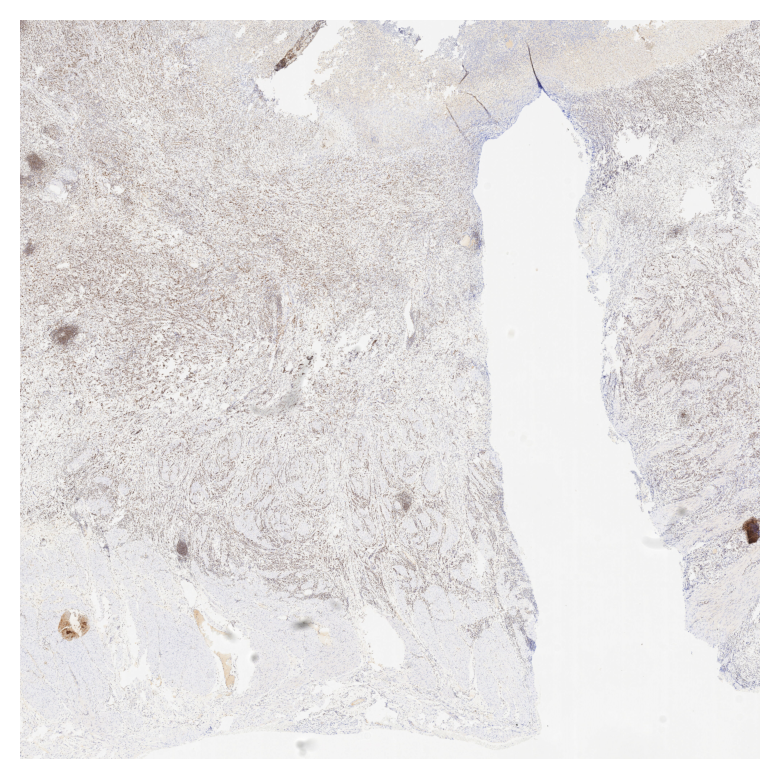

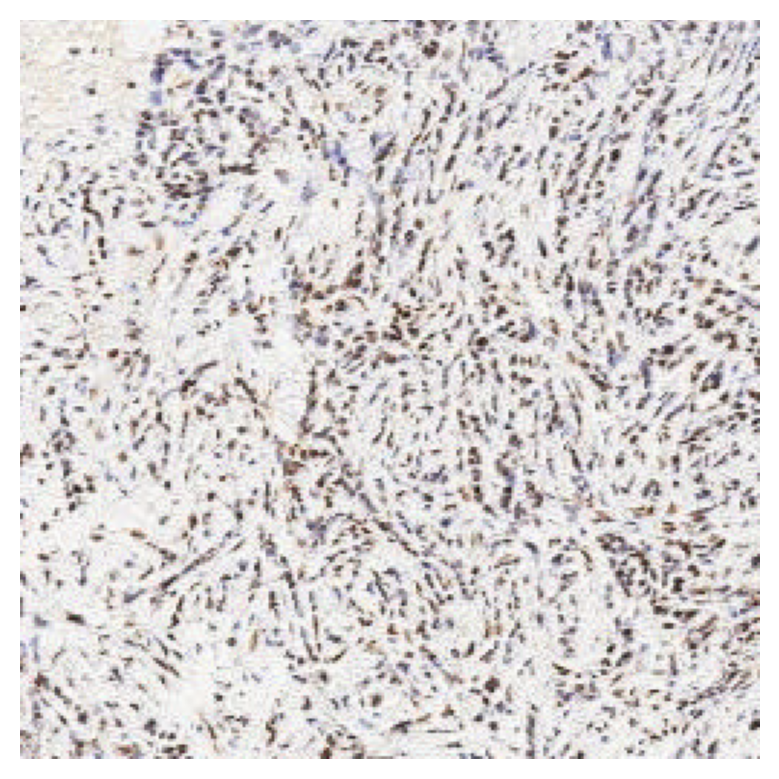

In [8]:
ihc_region = ihc_loader.load_region(level=load_level, offset=(3000, 3000), shape=(4096, 4096))
plt.figure(dpi=200)
plt.imshow(ihc_region)
plt.axis('off')

ihc_patch = ihc_loader.load_region(level=load_level, offset=(3000, 7000), shape=(256, 256))
plt.figure(dpi=200)
plt.imshow(ihc_patch)
plt.axis('off')

plt.show()

# 初始配准

In [ ]:
from deeperhistreg.dhr_pipeline.registration_params import default_initial

registration_params: dict = default_initial()
registration_params['loading_params']['loader'] = 'openslide'

# 其他配置
save_displacement_field: bool = True           # 保存位移场（用于后续 landmarks/分割变换）
save_svs: bool = True                          # 配准后的文件保存为 SVS 格式
copy_target: bool = False                      # 复制 target 到输出目录
delete_temporary_results: bool = True          # 删除临时结果

## H&E 到 IHC 配准

In [ ]:
case_name = "he2ihc_default_initial"
result_path: Union[str, pathlib.Path] = output_path / f"{case_name}_result"
temporary_path: Union[str, pathlib.Path] = output_path / f"{case_name}_tmp"

config = dict()
config['source_path'] = str(he_path)
config['target_path'] = str(ihc_path)
config['output_path'] = str(result_path)
config['registration_parameters'] = registration_params
config['case_name'] = case_name
config['save_displacement_field'] = save_displacement_field
config['save_svs'] = save_svs
config['copy_target'] = copy_target
config['delete_temporary_results'] = delete_temporary_results
config['temporary_path'] = str(temporary_path)

deeperhistreg.run_registration(**config)

/home/lzl/code/baseline/DeeperHistReg/deeperhistreg/dhr_pipeline/../dhr_registration/./dhr_initial_alignment/./superpoint_superglue.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

In [14]:
he2ihc_path = result_path / "warped_source.tiff"
he2ihc_loader = tiff_loader.TIFFLoader(he2ihc_path)

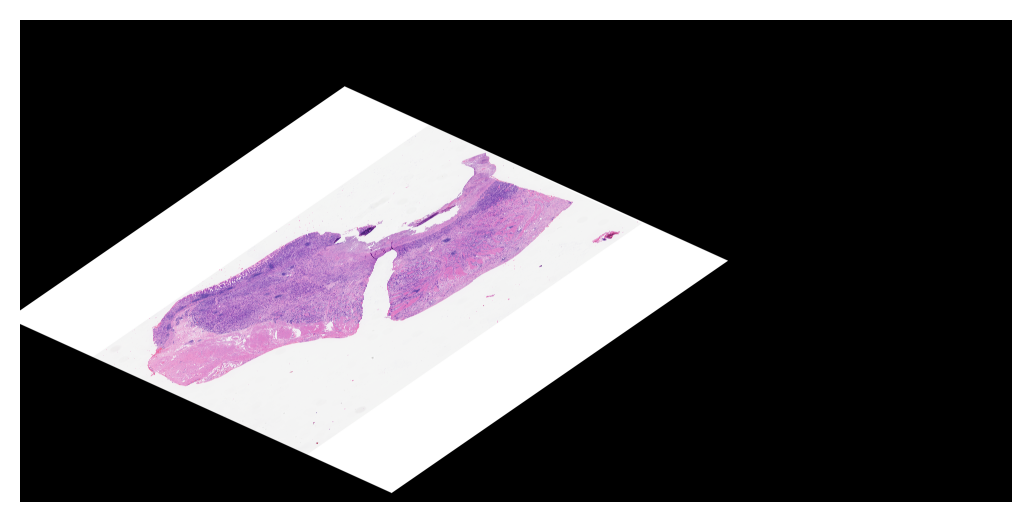

In [17]:
he2ihc = he2ihc_loader.load_level(level=1)

plt.figure(dpi=200)
plt.imshow(he2ihc)
plt.axis('off')

plt.show()

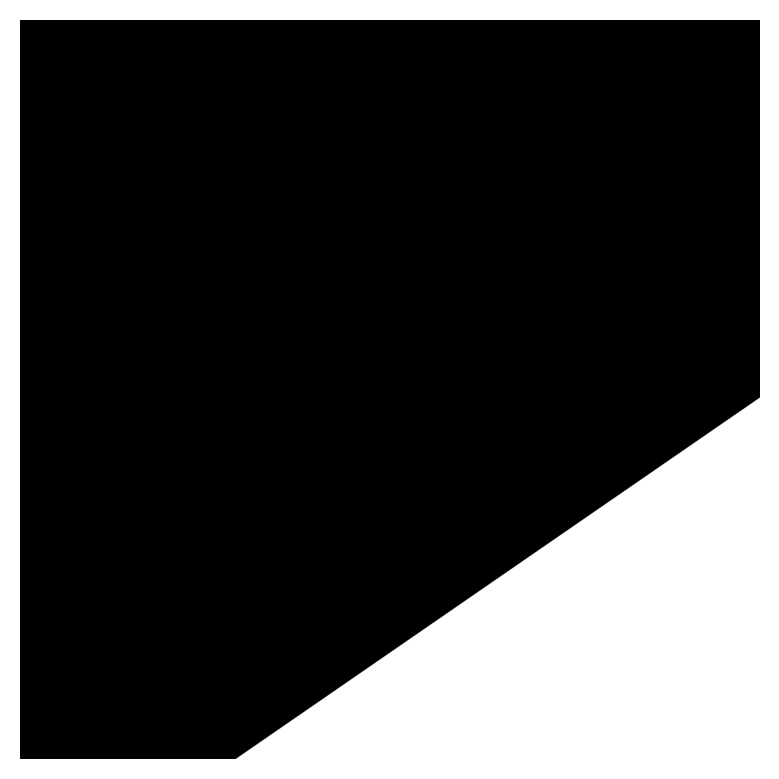

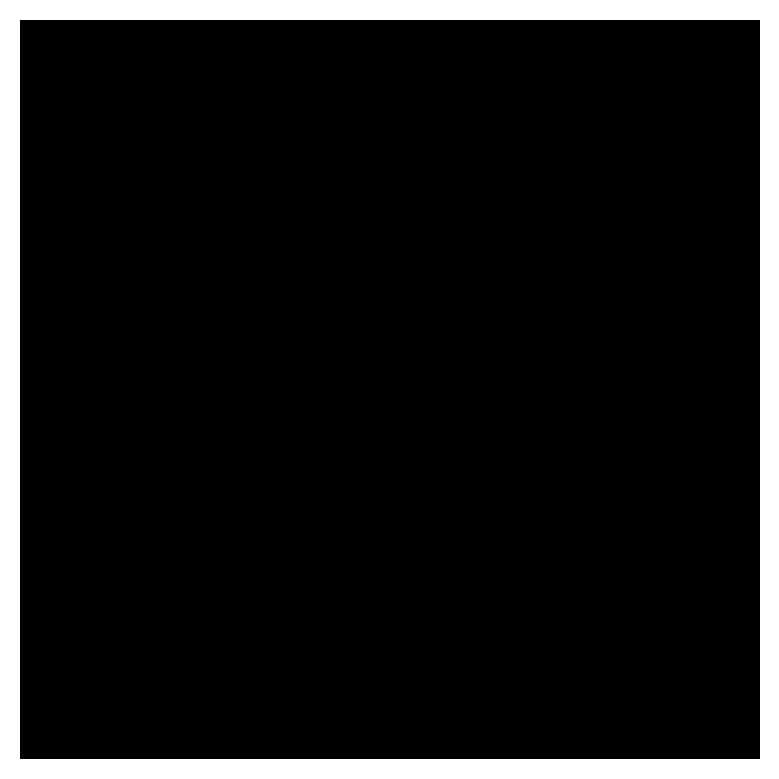

In [20]:
he2ihc_region = he2ihc_loader.load_region(level=load_level, offset=(3000, 3000), shape=(4096, 4096))
plt.figure(dpi=200)
plt.imshow(he2ihc_region)
plt.axis('off')

he2ihc_patch = he2ihc_loader.load_region(level=load_level, offset=(3000, 7000), shape=(256, 256))
plt.figure(dpi=200)
plt.imshow(he2ihc_patch)
plt.axis('off')

plt.show()

## IHC 到 H&E 配准

In [ ]:
# config = dict()
# config['source_path'] = str(ihc_path)
# config['target_path'] = str(he_path)
# config['output_path'] = str(output_path)
# config['registration_parameters'] = registration_params
# config['case_name'] = "ihc2he_default_initial"
# config['save_displacement_field'] = save_displacement_field
# config['copy_target'] = copy_target
# config['delete_temporary_results'] = delete_temporary_results